## Criação da esteira para Normalização das fotos
- Bloco utilizado para processar todas as imagens de treino e "formatar" para um formato padrão para podermos usar-las.

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Definindo as regras da nossa "esteira"
# rescale=1./255 faz a normalização (divide todos os pixels por 255)
gerador_de_dados = ImageDataGenerator(rescale=1./255)

# Caminho para a sua pasta de treino
caminho_treino = 'chest_xray/train'

# 2. Ligando a esteira e conectando na pasta
# O flow_from_directory lê a pasta, corta as imagens no target_size,
# agrupa em lotes (batch_size) e entende que temos 2 categorias (class_mode='binary')
dados_treino = gerador_de_dados.flow_from_directory(
    caminho_treino,
    target_size=(224, 224), # Forçando todas as imagens a terem altura 224 e largura 224
    batch_size=32,          # Ele vai processar 32 imagens por vez
    class_mode='binary'     # 0 para Normal, 1 para Pneumonia
)

# 3. Pegando o primeiro lote (batch) que saiu da esteira para inspecionar
imagens, rotulos = next(dados_treino)

print("\n--- Analisando o lote que saiu da esteira ---")
print("Formato do lote de imagens:", imagens.shape)
print("Formato do lote de rótulos (labels):", rotulos.shape)
print("Exemplo de rótulos:", rotulos[:5])
print("Maior valor de pixel agora:", imagens.max())

Found 5216 images belonging to 2 classes.

--- Analisando o lote que saiu da esteira ---
Formato do lote de imagens: (32, 224, 224, 3)
Formato do lote de rótulos (labels): (32,)
Exemplo de rótulos: [0. 1. 1. 1. 1.]
Maior valor de pixel agora: 1.0


## Proteção contra Overfitting: criação do Data Augmentation
- utilizado para aplicar uma leve "torção" para meio que centralizar as imagens fornecidas pela esteira anterior.


Conectando aos dados de Treinamento:
Found 5216 images belonging to 2 classes.

Conectando aos dados de Validação:
Found 16 images belonging to 2 classes.

Conectando aos dados de Teste:
Found 624 images belonging to 2 classes.


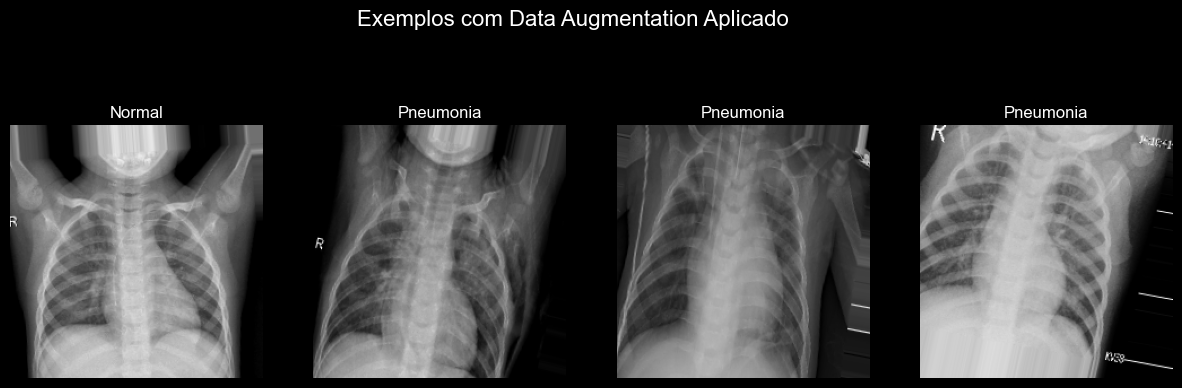

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Esteira de TREINO com Data Augmentation
# Adicionamos "ruídos" saudáveis para evitar o overfitting
gerador_treino = ImageDataGenerator(
    rescale=1./255,          # Normalização (obrigatória)
    rotation_range=15,       # Rotaciona aleatoriamente a imagem em até 15 graus
    width_shift_range=0.1,   # Desloca a imagem para a esquerda/direita em até 10%
    height_shift_range=0.1,  # Desloca a imagem para cima/baixo em até 10%
    zoom_range=0.1,          # Aplica um zoom in/out aleatório de até 10%
    horizontal_flip=True,    # Pode espelhar a imagem horizontalmente
    fill_mode='nearest'      # Preenche pixels vazios caso a imagem saia do quadro
)

# 2. Esteiras de VALIDAÇÃO e TESTE sem Augmentation
# Apenas normalizamos, pois queremos avaliar imagens reais, não imagens contorcidas
gerador_teste = ImageDataGenerator(rescale=1./255)

# Definindo caminhos
caminho_treino = 'chest_xray/train'
caminho_val = 'chest_xray/val'
caminho_teste = 'chest_xray/test'

# 3. Conectando as esteiras aos diretórios
print("\nConectando aos dados de Treinamento:")
dados_treino = gerador_treino.flow_from_directory(
    caminho_treino,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print("\nConectando aos dados de Validação:")
dados_val = gerador_teste.flow_from_directory(
    caminho_val,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print("\nConectando aos dados de Teste:")
dados_teste = gerador_teste.flow_from_directory(
    caminho_teste,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Não embaralhamos os testes para não perder a ordem na hora de avaliar
)

# --- BÔNUS VISUAL: Mostrando o Augmentation na Prática ---
# Pegamos apenas as imagens do primeiro lote (batch) gerado
imagens, rotulos = next(dados_treino)

# Vamos plotar as 4 primeiras imagens desse lote para ver como elas ficaram
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axes[i].imshow(imagens[i]) # Exibe a imagem processada

    # O rótulo é um número float (0.0 ou 1.0). Convertendo para o nome:
    titulo = "Pneumonia" if rotulos[i] == 1.0 else "Normal"
    axes[i].set_title(titulo)
    axes[i].axis('off')

plt.suptitle("Exemplos com Data Augmentation Aplicado", fontsize=16)
plt.show()